<h1><center>TD1 - Notebook 2 : Run your first Modflow model </center></h1>

### 1. Load Hydromodpy librairies 

In [1]:
# Libraries installed by default
import sys
import glob
import os
import fnmatch
import random
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*free variable*")
# Libraries need to be installed if not
import numpy as np
import pandas as pd
import shutil
from geopy.geocoders import Nominatim
# Libraries added from 'conda install' procedure
import geopandas as gpd
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.pylab as pl
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Libraries added from 'conda forge' procedure
from osgeo import gdal, osr # or import gdal
import rasterio
# Libraries installed from the pip procedure
import deepdish as dd
import flopy
import imageio
import vedo
import hydroeval
import xarray	
import netCDF4
import matplotlib_scalebar	
import contextily
import pyproj # uninstall before install
import selenium
import shapefile # named pyshp for install
import jupyter
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

embedWindow(verbose=True): could not load ipyvtklink try:
> pip install ipyvtklink


### 2. Complete your personal paths where hydromodpy sources are

In [2]:
# Fill in the directory where Hydromodpy codes are
root_dir = '/home/jean.marcais/Modeles/hydromodpy/HydroModPy'
root_dir = 'D:/Users/abherve/GITHUB/HydroModPy/'
# Add to the path the Hydromodpy directory to recognize HydroModpy functions, classes, etc.
sys.path.append(root_dir)
# Define the directory where the notebook is stored as the current working directory
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    print("Root path directory is: {0}".format(cwd))

Root path directory is: D:\Users\abherve\GITHUB\HydroModPy\teaching


##### Import the hydromodpy source files 

In [3]:
import src # import the folder src from HydroModpy codes
import importlib # 
importlib.reload(src)
# import all the classes necessary to extract the watershed from Hydromodpy source files.
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

##### Complete the paths where data are

In [4]:
# complete the data paths
teaching_path = root_dir + "/teaching/"
data_path = teaching_path + "/data/"
# complete where modflow sources are
modflow_path = os.path.join(root_dir,'bin/')
#
watershed_name = 'Glueyre'

### 3. Load the former watershed object

##### Complete the folder directory where data will be stored

In [5]:
out_path = '/home/jean.marcais/Bureau/tmp/hydromodpy/'
out_path = 'C:/Users/ronan/Documents/SIMULATIONS/HYDROMODPY/'
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'
simulations_folder = out_path+'/'+watershed_name+'/'+'results_simulations/'

##### Extract watershed contour from the watershed object created in TD1

In [6]:
print('##### '+watershed_name.upper()+' #####')
load=True
#load=False
#dem_path = data_path + 'BDAltiv2_75m.tif'
dem_path = ''
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              #from_xyv = [820019.377455, 6.41561849e+06, 75, 10, 'EPSG:2154'], # [x, y, snap distance, buffer size]
                              watershed_name=watershed_name,
                              modflow_path=modflow_path, 
                              save_object=False)

##### GLUEYRE #####
Object was loaded successfully


### 4. Extract the climate forcing data of the catchment

Initialize the climatic module and fill in with the climate data stored in your data folder

In [7]:
BV.add_climatic()
BV.climatic.update_recharge_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                       clim_mod='REA',
                                       clim_sce='historic',
                                       first_year=1990,
                                       last_year=2019,
                                       time_step='D',
                                       sim_state='transient')
BV.climatic.update_runoff_reanalysis(path_file=data_path+'_climate_REANALYSIS.csv',
                                     clim_mod='REA',
                                     clim_sce='historic',
                                     first_year=1990,
                                     last_year=2019,
                                     time_step='D',
                                     sim_state='transient')

Init climatic module to set model parameter


Visualize the climatic data available

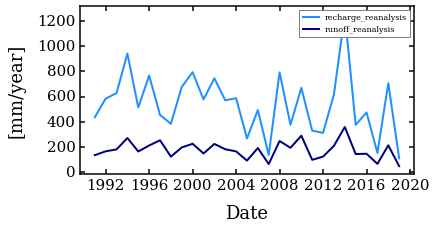

In [8]:
fig, ax = plt.subplots(1,1, figsize=(6,3))
R = BV.climatic.recharge.resample('Y').sum()*1000
r = BV.climatic.runoff.resample('Y').sum()*1000
ax.plot(R, label='recharge_reanalysis', c='dodgerblue', lw=2)
ax.plot(r, label='runoff_reanalysis', c='navy', lw=2)
ax.set_xlabel('Date')
ax.set_ylabel('[mm/year]')
ax.legend()

<em> These data consists of two time series extracted from Meteo France reanalysis and land surface model able to generate runoff and drain time series at 8x8 grid scale over France. Runoff time series represent the infiltration excess and saturation excess overland flow generated by the model. Drain time series represent the potential recharge time series occuring on this grid scale.</em>

In [9]:
box = True # or False
sink_fill = False # or True
# sim_state = 'transient' # 'steady' or 'transient'
sim_state = 'steady' # 'steady' or 'transient'
plot_cross = False
first_clim = 'mean'

In [10]:
nlay = 1
lay_decay = 1 # 1 for no decay
bottom = None # elevation in meters, None for constant auifer thickness, or 2D matrix
thick = 50 # if bottom is None, aquifer thickness
cond_decay = 0 # exponential decay : 1/20 (half decrease at 20m)
verti_cond = None # or [ [1e-5, [0, 20]],
                  #      [1e-6, [20,80]] ]
cond_drain = None # or value of conductance
porosity = 10 / 100 # -
hyd_cond = 1e-5 * 24 * 3600 # similar unit as the recharge [m/day]
poro_decay = 0 # exponential decay : 1/20 (half decrease at 20m)

In [11]:
bc_left = None # or value
bc_right = None # or value
sea_level = 'None' # or value based on specific data : BV.oceanic.MSL

In [12]:
BV.add_settings()
#BV.add_climatic()
BV.add_geometric() # soon
BV.add_hydraulic()

BV.settings.update_box_model(box)
BV.settings.update_sink_fill(sink_fill)
BV.settings.update_simulation_state(sim_state)
BV.settings.update_active_plot(plot_cross=plot_cross)

BV.climatic.update_first_clim(first_clim)

BV.hydraulic.update_nlay(nlay) # 1
BV.hydraulic.update_lay_decay(lay_decay) # 1
BV.hydraulic.update_bottom(bottom) # None
BV.hydraulic.update_thick(thick) # 30 / intervient pas si bottom != None
BV.hydraulic.update_porosity(porosity)
BV.hydraulic.update_hyd_cond(hyd_cond)
BV.hydraulic.update_cond_vertical(verti_cond)
BV.hydraulic.update_cond_drain(cond_drain)
BV.hydraulic.update_lay_decay(poro_decay)

BV.settings.update_bc_sides(bc_left, bc_right)
BV.add_oceanic(sea_level)

Init settings module to set model parameter
Init hydraulic module to set model parameter


In [13]:
iD_set_simulations = 'explorK_test1'

list_model_name = []
list_success_modflow = []
list_model_modflow = []

In [14]:
model_name = iD_set_simulations+'_'+str(round(hyd_cond,3))
BV.settings.update_model_name(model_name)
print(model_name)

model_modflow = BV.preprocessing_modflow()
success_modflow = BV.processing_modflow(model_modflow, write_model=True, run_model=True)
if success_modflow == True:
    BV.postprocessing_modflow(model_modflow,
                              watertable_elevation = True,
                              watertable_depth= True, 
                              seepage_areas = True,
                              outflow_drain = True,
                              groundwater_flux = True,
                              groundwater_storage = True,
                              accumulation_flux = True,
                              export_all_tif = False)

list_model_name.append(model_name)
list_success_modflow.append(success_modflow)
list_model_modflow.append(model_modflow)

explorK_test1_0.864
FloPy is using the following executable to run the model: D:/Users/abherve/GITHUB/HydroModPy/bin/win\mfnwt.exe

                                  MODFLOW-NWT-SWR1 
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUNDWATER-FLOW MODEL
                             WITH NEWTON FORMULATION
                             Version 1.3.0 07/01/2022                        
                    BASED ON MODFLOW-2005 Version 1.12.0 02/03/2017                       

                    SWR1 Version 1.05.0 03/10/2022                       

 Using NAME file: explorK_test1_0.864.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2023/09/11 12:27:05

 Solving:  Stress period:     1    Time step:     1    Groundwater-Flow Eqn.
 Run end date and time (yyyy/mm/dd hh:mm:ss): 2023/09/11 12:27:07
 Elapsed run time:  1.243 Seconds

  Normal termination of simulation
    Time:  0


In [15]:
timeseries_results = BV.postprocessing_timeseries(model_modflow=model_modflow,
                                                  model_modpath=None,
                                                  actual_date=True, 
                                                  subbasin_results=False)

Extract modflow and modpath results in timeseries


In [16]:
timeseries_results.mfdata

,recharge,watertable_elevation,watertable_depth,seepage_areas,outflow_drain,groundwater_flux,groundwater_storage,accumulation_flux
date,,,,,,,,
1990-01-01,1.07499e-03,8.10650e+02,3.98368e+01,2.85464e+00,1.50724e-03,7.69949e+01,7.18377e+07,1.06538e+05
1990-01-02,1.21238e-03,nan,nan,nan,nan,nan,nan,nan
1990-01-03,1.37368e-03,nan,nan,nan,nan,nan,nan,nan
1990-01-04,1.55575e-03,nan,nan,nan,nan,nan,nan,nan
1990-01-05,1.73738e-03,nan,nan,nan,nan,nan,nan,nan
...,...,...,...,...,...,...,...,...
2018-07-27,1.53297e-04,nan,nan,nan,nan,nan,nan,nan
2018-07-28,4.04979e-05,nan,nan,nan,nan,nan,nan,nan
2018-07-29,3.18528e-05,nan,nan,nan,nan,nan,nan,nan


In [ ]:
visu = visualization_results.Visualization(BV, model_name)
visu.visual2D(object_list = ['map','grid',
                             'watertable', 'watertable_depth',
                             'drain_flow', 'surface_flow',
                             #'pathlines', 'residence_times'
                             ],
              color_scale = [(None,None),(None,None),
                             (None,None),(0,10),
                             (None,None),(None,None),
                             #(None,None),(None,None),
                             ], 
              lines=100)

In [ ]:
dem_data = imageio.imread(stable_folder+'/geographic/'+'watershed_box_buff_dem.tif') # dem data
stream_data = imageio.imread(stable_folder+'/hydrography/'+'cours_eau_V.tif') # river data
watertable_data = imageio.imread(simulations_folder+model_name+'/_postprocess/_rasters/'+'watertable_elevation_t(0).tif') # watertable data
interactive = False
visu = visualization_results.Visualization(BV, model_name)
visu.interactive_cross_section(dem_data, watertable_data, stream_data, interactive)